# ============================================================
# PRACTICAL NO_02: Problem Solving through Search
#
# Name: Sakshi Kailas Shewale
# PRN: 202401040126
# Roll No.: 31
# Batch: A2
# Class: T.Y. B.Tech Computer Engineering
# Subject: Artificial Intelligence and Machine Learning
# ============================================================

### Search Strategy Comparison

Algorithms:
1. Breadth First Search (BFS)
2. Depth First Search (DFS)
3. A* Search
4. Hill Climbing
5. Backtracking for Constraint Satisfaction

## Part 1: Maze Pathfinding

We represent the maze as a grid-based state space.

Each free cell represents a state. The valid actions are:
- Up
- Down
- Left
- Right

The objective is to find a path from the start state to the goal state.

In [106]:
# Maze representation
# 0 = free cell
# 1 = wall

maze = [
    [0, 0, 0, 1, 0],
    [1, 0, 0, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)

print("Maze:")
for row in maze:
    print(row)

print("\nStart:", start)
print("Goal:", goal)

Maze:
[0, 0, 0, 1, 0]
[1, 0, 0, 1, 0]
[1, 1, 0, 0, 0]
[0, 0, 1, 1, 0]
[0, 0, 0, 0, 0]

Start: (0, 0)
Goal: (4, 4)


In [107]:
# Possible movements: Up, Down, Left, Right
directions = [
    (-1, 0),  # Up
    (1, 0),   # Down
    (0, -1),  # Left
    (0, 1)    # Right
]


def get_neighbors(position, maze):
    row, col = position
    neighbors = []

    rows = len(maze)
    cols = len(maze[0])

    for dr, dc in directions:
        new_row = row + dr
        new_col = col + dc

        # Check boundaries
        if 0 <= new_row < rows and 0 <= new_col < cols:

            # Check that the cell is not a wall
            if maze[new_row][new_col] == 0:
                neighbors.append((new_row, new_col))

    return neighbors


# Call the function outside the function
print("Neighbors of start:", get_neighbors(start, maze))

Neighbors of start: [(0, 1)]


## 1. Breadth First Search (BFS)

BFS is an uninformed search algorithm that explores the state space level by level.

It uses a FIFO (First-In, First-Out) queue and a visited set to avoid revisiting states.

For the maze problem, BFS finds the shortest path when every movement has equal cost.

In [108]:
#implement BFS
from collections import deque
import time


def bfs(maze, start, goal):
    # Queue stores: (current_position, path_taken)
    queue = deque([(start, [start])])

    # Keep track of visited cells
    visited = {start}

    # Performance metrics
    nodes_expanded = 0
    max_frontier = 1

    # Start timer
    start_time = time.perf_counter()

    while queue:

        # Remove the first element from the queue
        current, path = queue.popleft()

        # Count expanded node
        nodes_expanded += 1

        # Check whether goal is reached
        if current == goal:

            execution_time = time.perf_counter() - start_time

            return {
                "path": path,
                "path_length": len(path) - 1,
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "execution_time": execution_time
            }

        # Explore neighboring cells
        for neighbor in get_neighbors(current, maze):

            if neighbor not in visited:

                visited.add(neighbor)

                new_path = path + [neighbor]

                queue.append((neighbor, new_path))

        # Update maximum queue size
        max_frontier = max(max_frontier, len(queue))

    # If no path exists
    execution_time = time.perf_counter() - start_time

    return {
        "path": None,
        "path_length": None,
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "execution_time": execution_time
    }

In [109]:
#metrics
result_bfs = bfs(maze, start, goal)

print("===== BFS RESULTS =====")

print("Path:", result_bfs["path"])
print("Path Length:", result_bfs["path_length"])
print("Nodes Expanded:", result_bfs["nodes_expanded"])
print("Maximum Frontier Size:", result_bfs["max_frontier"])
print("Execution Time:", result_bfs["execution_time"], "seconds")

===== BFS RESULTS =====
Path: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Path Length: 8
Nodes Expanded: 12
Maximum Frontier Size: 2
Execution Time: 4.874600017501507e-05 seconds


In [110]:
#visualization of at least one final path.
#here:S = Start ; G = Goal ; # = Wall ; * = BFS path ; . = Free cell not used

def display_path(maze, path):
    display_grid = []

    for r in range(len(maze)):
        row = []

        for c in range(len(maze[0])):

            if (r, c) == start:
                row.append("S")

            elif (r, c) == goal:
                row.append("G")

            elif path and (r, c) in path:
                row.append("*")

            elif maze[r][c] == 1:
                row.append("#")

            else:
                row.append(".")

        display_grid.append(row)

    for row in display_grid:
        print(" ".join(row))


display_path(maze, result_bfs["path"])

S * . # .
# * * # .
# # * * *
. . # # *
. . . . G


## 2. Depth First Search (DFS)

DFS is an uninformed search algorithm that explores one branch of the search space as deeply as possible before backtracking.

It uses a LIFO (Last-In, First-Out) stack and a visited set to avoid revisiting states.

DFS can find a path to the goal, but it does not guarantee the shortest path in a general unweighted graph.

In [111]:
#implement DFS
def dfs(maze, start, goal):
    # Stack stores: (current_position, path_taken)
    stack = [(start, [start])]

    # Keep track of visited cells
    visited = {start}

    # Performance metrics
    nodes_expanded = 0
    max_frontier = 1

    # Start timer
    start_time = time.perf_counter()

    while stack:

        # Remove the last element from the stack
        current, path = stack.pop()

        # Count expanded node
        nodes_expanded += 1

        # Check whether goal is reached
        if current == goal:

            execution_time = time.perf_counter() - start_time

            return {
                "path": path,
                "path_length": len(path) - 1,
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "execution_time": execution_time
            }

        # Explore neighboring cells
        for neighbor in get_neighbors(current, maze):

            if neighbor not in visited:

                visited.add(neighbor)

                new_path = path + [neighbor]

                stack.append((neighbor, new_path))

        # Update maximum stack size
        max_frontier = max(max_frontier, len(stack))

    # If no path exists
    execution_time = time.perf_counter() - start_time

    return {
        "path": None,
        "path_length": None,
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "execution_time": execution_time
    }

In [112]:
#Metrics
result_dfs = dfs(maze, start, goal)

print("===== DFS RESULTS =====")

print("Path:", result_dfs["path"])
print("Path Length:", result_dfs["path_length"])
print("Nodes Expanded:", result_dfs["nodes_expanded"])
print("Maximum Frontier Size:", result_dfs["max_frontier"])
print("Execution Time:", result_dfs["execution_time"], "seconds")

===== DFS RESULTS =====
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Path Length: 8
Nodes Expanded: 9
Maximum Frontier Size: 3
Execution Time: 5.1639000048453454e-05 seconds


In [19]:
#visualization
print("===== DFS PATH =====")

display_path(maze, result_dfs["path"])

===== DFS PATH =====
S * * # .
# . * # .
# # * * *
. . # # *
. . . . G


## 3. A* Search

A* is an informed search algorithm that uses both the actual cost from the start state and a heuristic estimate to the goal.

It uses the evaluation function:

f(n) = g(n) + h(n)

where:
- g(n) = cost from the start node to the current node
- h(n) = estimated cost from the current node to the goal
- f(n) = total estimated cost

For the grid maze, Manhattan distance is used as the heuristic because movement is allowed only in four directions.

In [113]:
import heapq

def manhattan_distance(position, goal):
    row1, col1 = position
    row2, col2 = goal

    return abs(row1 - row2) + abs(col1 - col2)

In [114]:
#implement A* algorithm
def astar(maze, start, goal):
    priority_queue = []

    # (f_cost, g_cost, current_position, path)
    heapq.heappush(priority_queue, (0, 0, start, [start]))

    g_costs = {start: 0}
    nodes_expanded = 0
    max_frontier = 1

    start_time = time.perf_counter()

    while priority_queue:
        f_cost, current_g, current, path = heapq.heappop(priority_queue)

        nodes_expanded += 1

        if current == goal:
            execution_time = time.perf_counter() - start_time

            return {
                "path": path,
                "path_length": len(path) - 1,
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "execution_time": execution_time
            }

        for neighbor in get_neighbors(current, maze):

            new_g = current_g + 1

            if neighbor not in g_costs or new_g < g_costs[neighbor]:

                g_costs[neighbor] = new_g

                h_cost = manhattan_distance(neighbor, goal)
                new_f = new_g + h_cost

                new_path = path + [neighbor]

                heapq.heappush(
                    priority_queue,
                    (new_f, new_g, neighbor, new_path)
                )

        max_frontier = max(max_frontier, len(priority_queue))

    execution_time = time.perf_counter() - start_time

    return {
        "path": None,
        "path_length": None,
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "execution_time": execution_time
    }

In [115]:
#Run A*
result_astar = astar(maze, start, goal)

print("===== A* RESULTS =====")
print("Path:", result_astar["path"])
print("Path Length:", result_astar["path_length"])
print("Nodes Expanded:", result_astar["nodes_expanded"])
print("Maximum Frontier Size:", result_astar["max_frontier"])
print("Execution Time:", result_astar["execution_time"], "seconds")

===== A* RESULTS =====
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Path Length: 8
Nodes Expanded: 10
Maximum Frontier Size: 2
Execution Time: 5.368900019675493e-05 seconds


In [116]:
#visualize A*
print("===== A* PATH =====")
display_path(maze, result_astar["path"])

===== A* PATH =====
S * * # .
# . * # .
# # * * *
. . # # *
. . . . G


In [117]:
#comparison between BFS, DFS and A*
print("===== SEARCH COMPARISON =====")

print("BFS  -> Path Length:", result_bfs["path_length"],
      "| Nodes Expanded:", result_bfs["nodes_expanded"])

print("DFS  -> Path Length:", result_dfs["path_length"],
      "| Nodes Expanded:", result_dfs["nodes_expanded"])

print("A*   -> Path Length:", result_astar["path_length"],
      "| Nodes Expanded:", result_astar["nodes_expanded"])

===== SEARCH COMPARISON =====
BFS  -> Path Length: 8 | Nodes Expanded: 12
DFS  -> Path Length: 8 | Nodes Expanded: 9
A*   -> Path Length: 8 | Nodes Expanded: 10


## Part 2: Multiple Maze Instances

To evaluate the performance of BFS, DFS and A*, three maze instances are used:

- Easy Maze: Small search space
- Medium Maze: Larger search space with more obstacles
- Hard Maze: Larger and more complex search space

All three algorithms use the same start and goal positions for each maze.

In [28]:
#created easy maze
easy_maze = [
    [0, 0, 0, 1, 0],
    [1, 0, 0, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0]
]

easy_start = (0, 0)
easy_goal = (4, 4)

print("===== EASY MAZE =====")

for row in easy_maze:
    print(row)

print("Start:", easy_start)
print("Goal:", easy_goal)

===== EASY MAZE =====
[0, 0, 0, 1, 0]
[1, 0, 0, 1, 0]
[1, 1, 0, 0, 0]
[0, 0, 1, 1, 0]
[0, 0, 0, 0, 0]
Start: (0, 0)
Goal: (4, 4)


In [119]:
#create medium maze
medium_maze = [
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 1, 0, 1, 1, 1, 0, 1],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 1],
    [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
    [0, 1, 1, 1, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
    [1, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 0, 1, 1, 1, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
]

medium_start = (0, 0)
medium_goal = (9, 9)

print("===== MEDIUM MAZE =====")

for row in medium_maze:
    print(row)

print("Start:", medium_start)
print("Goal:", medium_goal)

===== MEDIUM MAZE =====
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 1, 0, 1, 1, 1, 0, 1]
[0, 1, 0, 1, 0, 1, 0, 0, 0, 1]
[0, 1, 0, 0, 0, 1, 0, 1, 1, 1]
[0, 1, 1, 1, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 1, 1, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
Start: (0, 0)
Goal: (9, 9)


In [118]:
#create hard maze
hard_maze = [
    [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
]

hard_start = (0, 0)
hard_goal = (14, 14)

print("===== HARD MAZE =====")

for row in hard_maze:
    print(row)

print("Start:", hard_start)
print("Goal:", hard_goal)

===== HARD MAZE =====
[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]
[1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1]
[1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Start: (0, 0)
Goal: (14, 14)


## Part 3: Performance Evaluation of BFS, DFS and A*

BFS, DFS and A* are evaluated on the three maze instances.

The following performance metrics are recorded:

- Path Length
- Nodes Expanded
- Maximum Frontier Size
- Execution Time

In [120]:
#comparison of bfs,dfs and A*
def run_experiment(maze, start, goal, maze_name):

    bfs_result = bfs(maze, start, goal)
    dfs_result = dfs(maze, start, goal)
    astar_result = a_star(maze, start, goal)

    results = [
        {
            "Maze": maze_name,
            "Algorithm": "BFS",
            "Path Length": bfs_result["path_length"],
            "Nodes Expanded": bfs_result["nodes_expanded"],
            "Max Frontier": bfs_result["max_frontier"],
            "Execution Time": bfs_result["execution_time"]
        },
        {
            "Maze": maze_name,
            "Algorithm": "DFS",
            "Path Length": dfs_result["path_length"],
            "Nodes Expanded": dfs_result["nodes_expanded"],
            "Max Frontier": dfs_result["max_frontier"],
            "Execution Time": dfs_result["execution_time"]
        },
        {
            "Maze": maze_name,
            "Algorithm": "A*",
            "Path Length": astar_result["path_length"],
            "Nodes Expanded": astar_result["nodes_expanded"],
            "Max Frontier": astar_result["max_frontier"],
            "Execution Time": astar_result["execution_time"]
        }
    ]

    return results

In [121]:
all_results = []

all_results.extend(
    run_experiment(
        easy_maze,
        easy_start,
        easy_goal,
        "Easy"
    )
)

all_results.extend(
    run_experiment(
        medium_maze,
        medium_start,
        medium_goal,
        "Medium"
    )
)

all_results.extend(
    run_experiment(
        hard_maze,
        hard_start,
        hard_goal,
        "Hard"
    )
)

print("All experiments completed successfully.")

All experiments completed successfully.


In [122]:
import pandas as pd

results_df = pd.DataFrame(all_results)

results_df

,Maze,Algorithm,Path Length,Nodes Expanded,Max Frontier,Execution Time
0,Easy,BFS,8,12,2,0.000043
1,Easy,DFS,8,9,3,0.000018
2,Easy,A*,8,10,2,0.000030
3,Medium,BFS,18,45,5,0.000092
4,Medium,DFS,40,41,8,0.000079
5,Medium,A*,18,27,7,0.000072
6,Hard,BFS,28,48,2,0.000100
7,Hard,DFS,28,78,4,0.000163
8,Hard,A*,28,30,3,0.000064


In [123]:
results_df.to_csv("search_results.csv", index=False)

print("Results saved to search_results.csv")

Results saved to search_results.csv


In [124]:
# visualize the Hard Maze A* path
hard_astar_result = a_star(hard_maze, hard_start, hard_goal)

print("===== HARD MAZE - A* PATH =====")
display_path(hard_maze, hard_astar_result["path"])

===== HARD MAZE - A* PATH =====
S * * # # # # # # # # # # # #
# # * * * * * * * * * * * * #
# . . # # # # # # # # # # * #
# . # # . . . . . . . . # * #
# . # . G # # # # # # . # * #
# . # . # # . . . . # . # * #
# . # . # . . # # . # . # * #
# . # . # . # # . . # . # * #
# . # . # . . . . # # . # * #
# . # . # # # # . . . . # * #
# . # . . . . # # # # # # * #
# . # # # # . . . . . . . * #
# . . . . . # # # # # # # * #
# # # # # # # # # # # # # * #
# # # # # # # # # # # # # * *


Part 4: Graph Representation of BFS, DFS and A*

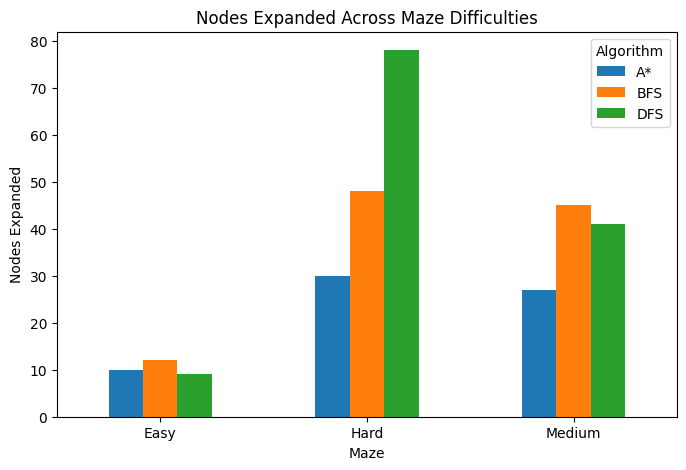

In [126]:
#1] 3-maze Nodes Expanded graph
import matplotlib.pyplot as plt

pivot_nodes = results_df.pivot(
    index="Maze",
    columns="Algorithm",
    values="Nodes Expanded"
)

pivot_nodes.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Nodes Expanded Across Maze Difficulties")
plt.xlabel("Maze")
plt.ylabel("Nodes Expanded")
plt.xticks(rotation=0)
plt.legend(title="Algorithm")
plt.show()

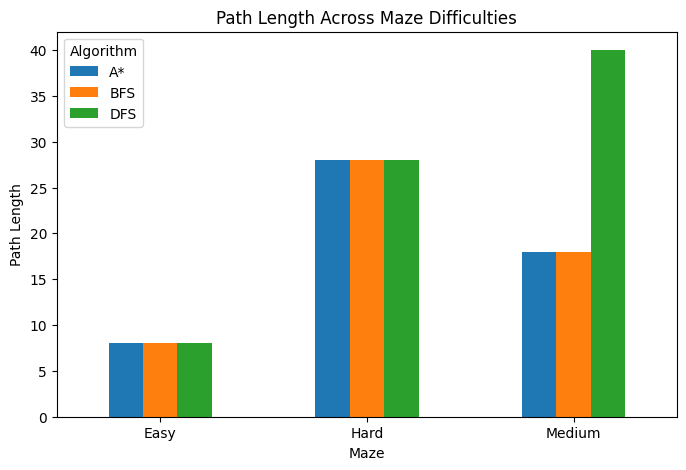

In [127]:
#2] path-length graph
pivot_path = results_df.pivot(
    index="Maze",
    columns="Algorithm",
    values="Path Length"
)

pivot_path.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Path Length Across Maze Difficulties")
plt.xlabel("Maze")
plt.ylabel("Path Length")
plt.xticks(rotation=0)
plt.legend(title="Algorithm")
plt.show()

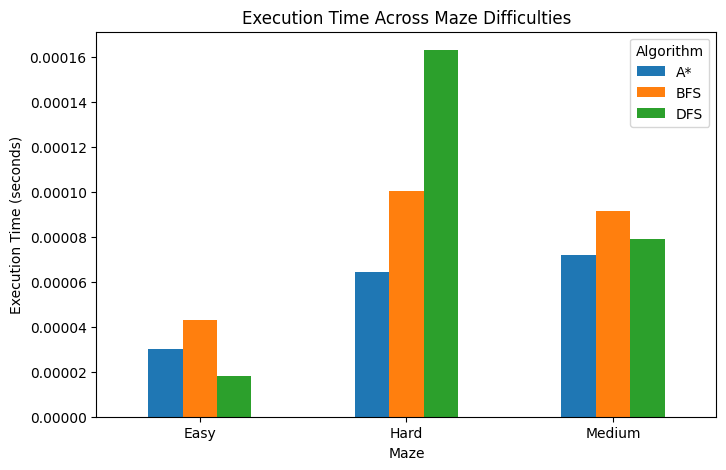

In [128]:
#3] execution time-graph
pivot_time = results_df.pivot(
    index="Maze",
    columns="Algorithm",
    values="Execution Time"
)

pivot_time.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Execution Time Across Maze Difficulties")
plt.xlabel("Maze")
plt.ylabel("Execution Time (seconds)")
plt.xticks(rotation=0)
plt.legend(title="Algorithm")
plt.show()

## Part 5: Local Search — Hill Climbing

The 8-Queens problem is used to demonstrate local search.

The objective is to place 8 queens on an 8×8 chessboard such that no two queens attack each other.

A state is represented as a list of 8 integers, where the index represents the column and the value represents the row of the queen.

The objective function is the number of attacking pairs of queens.

The goal is to minimize the number of conflicts until it becomes 0. *italicized text*

In [129]:
#create conflict function
import random

def calculate_conflicts(state):
    conflicts = 0
    n = len(state)

    for i in range(n):
        for j in range(i + 1, n):

            # Same row
            if state[i] == state[j]:
                conflicts += 1

            # Same diagonal
            if abs(state[i] - state[j]) == abs(i - j):
                conflicts += 1

    return conflicts

In [130]:
#Test the function
test_state = [0, 2, 4, 1, 3, 5, 7, 6]

print("State:", test_state)
print("Conflicts:", calculate_conflicts(test_state))

State: [0, 2, 4, 1, 3, 5, 7, 6]
Conflicts: 4


### Hill Climbing Algorithm

Hill Climbing starts with a random solution and repeatedly moves to a neighboring state with fewer conflicts.

If no better neighboring state exists, the algorithm stops.

Because Hill Climbing can get stuck in a local optimum, multiple random restarts can be used to improve the chance of finding a solution.

In [131]:
# 8-queen problem
def hill_climbing_8_queens(max_restarts=100):

    n = 8

    total_states_evaluated = 0
    start_time = time.perf_counter()

    for restart in range(max_restarts):

        state = [random.randint(0, n - 1) for _ in range(n)]

        current_conflicts = calculate_conflicts(state)

        while True:

            best_state = state[:]
            best_conflicts = current_conflicts

            for column in range(n):

                for row in range(n):

                    if row == state[column]:
                        continue

                    neighbor = state[:]
                    neighbor[column] = row

                    total_states_evaluated += 1

                    conflicts = calculate_conflicts(neighbor)

                    if conflicts < best_conflicts:
                        best_state = neighbor
                        best_conflicts = conflicts

            if best_conflicts >= current_conflicts:
                break

            state = best_state
            current_conflicts = best_conflicts

            if current_conflicts == 0:

                execution_time = time.perf_counter() - start_time

                return {
                    "solution": state,
                    "conflicts": 0,
                    "restarts": restart + 1,
                    "states_evaluated": total_states_evaluated,
                    "execution_time": execution_time
                }

    execution_time = time.perf_counter() - start_time

    return {
        "solution": None,
        "conflicts": current_conflicts,
        "restarts": max_restarts,
        "states_evaluated": total_states_evaluated,
        "execution_time": execution_time
    }

In [132]:
result_hill = hill_climbing_8_queens()

print("===== HILL CLIMBING RESULTS =====")
print("Solution:", result_hill["solution"])
print("Conflicts:", result_hill["conflicts"])
print("Restarts:", result_hill["restarts"])
print("States Evaluated:", result_hill["states_evaluated"])
print("Execution Time:", result_hill["execution_time"], "seconds")

===== HILL CLIMBING RESULTS =====
Solution: [5, 2, 6, 1, 7, 4, 0, 3]
Conflicts: 0
Restarts: 2
States Evaluated: 448
Execution Time: 0.0036832260002483963 seconds


In [133]:
if result_hill["solution"] is not None:
    print("===== 8-QUEENS SOLUTION =====")
    display_chessboard(result_hill["solution"])

===== 8-QUEENS SOLUTION =====
. . . . . . Q .
. . . Q . . . .
. Q . . . . . .
. . . . . . . Q
. . . . . Q . .
Q . . . . . . .
. . Q . . . . .
. . . . Q . . .


## Part 6. Backtracking (CSP) – 8-Queens

Backtracking is a systematic search technique used to solve Constraint Satisfaction Problems (CSPs).

In the 8-Queens problem, queens are placed row by row while checking whether each placement satisfies the constraints.

If a placement leads to a dead end, the algorithm backtracks to the previous row and tries another possible position.

In [134]:
#implementation
def is_safe(board, row, column):

    # Check the same column
    for previous_row in range(row):
        if board[previous_row] == column:
            return False

    # Check diagonals
    for previous_row in range(row):

        if abs(board[previous_row] - column) == abs(previous_row - row):
            return False

    return True

In [135]:
#implement backtracking algorithm
def backtracking_8_queens():

    n = 8

    # board[row] stores the column of the queen
    board = [-1] * n

    nodes_expanded = 0
    start_time = time.perf_counter()

    def solve(row):

        nonlocal nodes_expanded

        # All queens have been placed
        if row == n:
            return True

        # Try every column in this row
        for column in range(n):

            nodes_expanded += 1

            # Check whether the position is valid
            if is_safe(board, row, column):

                # Place queen
                board[row] = column

                # Move to the next row
                if solve(row + 1):
                    return True

                # Backtrack
                board[row] = -1

        return False

    success = solve(0)

    execution_time = time.perf_counter() - start_time

    if success:
        return {
            "solution": board,
            "nodes_expanded": nodes_expanded,
            "execution_time": execution_time
        }

    return {
        "solution": None,
        "nodes_expanded": nodes_expanded,
        "execution_time": execution_time
    }

In [136]:
#run backtracking
result_backtracking = backtracking_8_queens()

print("===== BACKTRACKING RESULTS =====")

print("Solution:", result_backtracking["solution"])
print("Nodes Expanded:", result_backtracking["nodes_expanded"])
print("Execution Time:", result_backtracking["execution_time"], "seconds")

===== BACKTRACKING RESULTS =====
Solution: [0, 4, 7, 5, 2, 6, 1, 3]
Nodes Expanded: 876
Execution Time: 0.0005660150000039721 seconds


In [137]:
#visualization
if result_backtracking["solution"] is not None:
    print("===== 8-QUEENS BACKTRACKING SOLUTION =====")
    display_chessboard(result_backtracking["solution"])

===== 8-QUEENS BACKTRACKING SOLUTION =====
Q . . . . . . .
. . . . . . Q .
. . . . Q . . .
. . . . . . . Q
. Q . . . . . .
. . . Q . . . .
. . . . . Q . .
. . Q . . . . .


## part 7. Comparison of 8-Queens Search Algorithms

Hill Climbing and Backtracking are compared based on their ability to find a valid 8-Queens solution, search effort, and execution time.

In [138]:
#comparison of hill climbing and backtracking
queens_results = pd.DataFrame({
    "Algorithm": ["Hill Climbing", "Backtracking"],
    "Solution Found": [
        result_hill["solution"] is not None,
        result_backtracking["solution"] is not None
    ],
    "Conflicts": [
        result_hill["conflicts"],
        0 if result_backtracking["solution"] is not None else None
    ],
    "Restarts": [
        result_hill["restarts"],
        "-"
    ],
    "Nodes Expanded": [
        "-",
        result_backtracking["nodes_expanded"]
    ],
    "Execution Time (seconds)": [
        "-",
        result_backtracking["execution_time"]
    ]
})

queens_results

,Algorithm,Solution Found,Conflicts,Restarts,Nodes Expanded,Execution Time (seconds)
0,Hill Climbing,True,0,2,-,-
1,Backtracking,True,0,-,876,0.000566


## Part 8: 8-Queens Experimental Comparison

Hill Climbing and Backtracking are compared based on solution quality, search effort, and execution time.

In [139]:
print("===== 8-QUEENS COMPARISON =====")

print("\nHill Climbing")
print("Solution Found:", result_hill["solution"] is not None)
print("Conflicts:", result_hill["conflicts"])
print("Restarts:", result_hill["restarts"])

print("\nBacktracking")
print("Solution Found:", result_backtracking["solution"] is not None)
print("Nodes Expanded:", result_backtracking["nodes_expanded"])
print("Execution Time:", result_backtracking["execution_time"], "seconds")

===== 8-QUEENS COMPARISON =====

Hill Climbing
Solution Found: True
Conflicts: 0
Restarts: 2

Backtracking
Solution Found: True
Nodes Expanded: 876
Execution Time: 0.0005660150000039721 seconds


### Part 9 - Graph Representation of Hill climbing and Backtracking

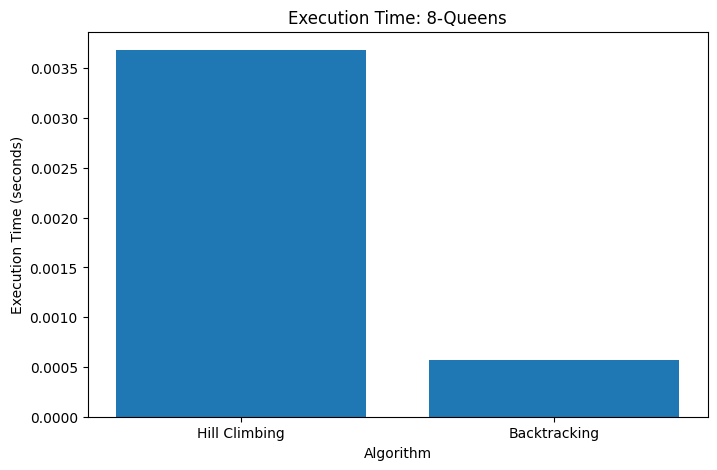

In [140]:
#1] 8-queen Execution time graphqueens_algorithms = ["Hill Climbing", "Backtracking"]

queens_algorithms = ["Hill Climbing", "Backtracking"]

queens_times = [
    result_hill["execution_time"],
    result_backtracking["execution_time"]
]

plt.figure(figsize=(8, 5))

plt.bar(queens_algorithms, queens_times)

plt.title("Execution Time: 8-Queens")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (seconds)")

plt.show()

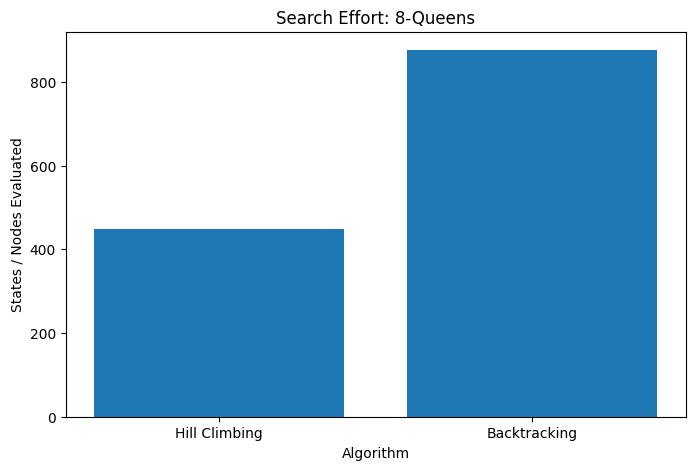

In [141]:
#2] search effort
queens_algorithms = ["Hill Climbing", "Backtracking"]

search_effort = [
    result_hill["states_evaluated"],
    result_backtracking["nodes_expanded"]
]

plt.figure(figsize=(8, 5))

plt.bar(queens_algorithms, search_effort)

plt.title("Search Effort: 8-Queens")
plt.xlabel("Algorithm")
plt.ylabel("States / Nodes Evaluated")

plt.show()

## Part 10. Analysis and Discussion

### Maze Search

BFS, DFS, and A* were evaluated on Easy, Medium, and Hard maze instances using path length, nodes expanded, maximum frontier size, and execution time.

BFS explores the maze level by level and guarantees a shortest path in an unweighted maze. Therefore, its path length provides a useful baseline for comparison.

DFS follows one branch deeply before backtracking. It may reach the goal after expanding fewer nodes on some maze instances, but the resulting path is not guaranteed to be optimal in general.

A* uses the Manhattan distance heuristic along with the actual path cost. Since movement is restricted to four directions and each move has equal cost, Manhattan distance is an appropriate heuristic for this maze representation. A* can use this information to guide its search toward the goal.

The experimental results should be interpreted across all three maze instances rather than from execution time alone. Because the mazes are relatively small, execution-time differences are very small and can be affected by Python runtime overhead. Nodes expanded, path length, and frontier size therefore provide useful additional measures of search behavior.

### 8-Queens Search

Hill Climbing and Backtracking were applied to the 8-Queens problem.

Hill Climbing attempts to improve the current state by moving toward a state with fewer conflicts. Because it is a local search method, it can become stuck at a state from which no improving move is available. Random restarts help it continue searching from a new initial state.

Backtracking uses systematic constraint checking. A queen is placed only when it does not conflict with previously placed queens. If a later placement becomes impossible, the algorithm backtracks and tries another position.

Both approaches successfully produced valid 8-Queens solutions in the experiment. Their search behavior is different: Hill Climbing uses local improvement and may require restarts, while Backtracking systematically explores candidate assignments and eliminates invalid partial solutions through constraint checking.

## Part 11. Conclusion

This practical demonstrated five search strategies: Breadth First Search, Depth First Search, A* Search, Hill Climbing, and Backtracking.

BFS, DFS, and A* were applied to grid-based maze pathfinding. The experiments showed how different search strategies explore the same state space in different ways. BFS provides shortest-path guarantees for unweighted mazes, DFS performs depth-oriented exploration, and A* uses heuristic information to guide the search.

Hill Climbing and Backtracking were applied to the 8-Queens constraint problem. Hill Climbing demonstrated local search with random restarts, while Backtracking demonstrated systematic constraint-based search.

The experiments demonstrate that there is no single search strategy that is appropriate for every problem. The choice of algorithm depends on the problem representation, whether an optimal solution is required, the available heuristic information, memory requirements, and the structure of the search space.

### Part 12. Summary Table

In [142]:
final_summary = pd.DataFrame({
    "Algorithm": [
        "BFS",
        "DFS",
        "A*",
        "Hill Climbing",
        "Backtracking"
    ],
    "Problem": [
        "Maze",
        "Maze",
        "Maze",
        "8-Queens",
        "8-Queens"
    ],
    "Search Type": [
        "Uninformed",
        "Uninformed",
        "Informed",
        "Local Search",
        "CSP / Systematic Search"
    ],
    "Main Strategy": [
        "Level-by-level exploration",
        "Depth-first exploration",
        "Cost + heuristic",
        "Improve local state",
        "Assign and backtrack"
    ]
})

final_summary

,Algorithm,Problem,Search Type,Main Strategy
0,BFS,Maze,Uninformed,Level-by-level exploration
1,DFS,Maze,Uninformed,Depth-first exploration
2,A*,Maze,Informed,Cost + heuristic
3,Hill Climbing,8-Queens,Local Search,Improve local state
4,Backtracking,8-Queens,CSP / Systematic Search,Assign and backtrack
